# EDA and Preprocessing - Explainability AI Hackathon
## ESILV A4

Team: Ziyad BRIAND, Omar BARI, Alvaro SERERO, Rithiga VENGADESSANE

In [2]:
# Install dependencies as needed:
# !pip install kagglehub[pandas-datasets]
# !pip install -r requirements.txt

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

## 1. Load the dataset

In [4]:
# Download latest version
path = kagglehub.dataset_download("rhuebner/human-resources-data-set")
# Use local path as alternative if kagglehub doesn't work
if not path or path == '':
    path = '../data/raw/HRDataset_v14.csv'

print("Path to dataset files:", path)

Path to dataset files: /Users/alvaro/.cache/kagglehub/datasets/rhuebner/human-resources-data-set/versions/4


In [5]:
# Load the dataset into a DataFrame
df = pd.read_csv(f"{path}/HRDataset_v14.csv")

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape: (311, 36)
Columns: ['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID', 'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID', 'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB', 'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus', 'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30', 'Absences']


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3


In [6]:
# Quick overview
print('Data types')
print(df.dtypes)
print('\nMissing values')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nTarget distribution')
print(df['Termd'].value_counts())
print(f"\nAttrition rate: {df['Termd'].mean():.1%}")

Data types
Employee_Name                     str
EmpID                           int64
MarriedID                       int64
MaritalStatusID                 int64
GenderID                        int64
EmpStatusID                     int64
DeptID                          int64
PerfScoreID                     int64
FromDiversityJobFairID          int64
Salary                          int64
Termd                           int64
PositionID                      int64
Position                          str
State                             str
Zip                             int64
DOB                               str
Sex                               str
MaritalDesc                       str
CitizenDesc                       str
HispanicLatino                    str
RaceDesc                          str
DateofHire                        str
DateofTermination                 str
TermReason                        str
EmploymentStatus                  str
Department                        str
M

## 2. GDPR Anonymization

We remove and transform all personal identifiers like employee name or zip code before any analysis for anonymization and RGPD compliance.

- The following columns identifiying each employee are dropped: 'Employee_Name', 'EmpID', 'Zip', 'State', 'DOB', 'DateofHire', 'DateofTermination', 'ManagerName', 'ManagerID'
- A 'tenure_days' column is computed from 'DateofHire' and 'DateofTermination'.
- Date of birth is converted to an 'age_group' categorization (20s, 30s, 40s, 50s+).
- Sensitive columns like 'Sex', 'RaceDesc', 'HispanicLatino' are dropped and kept in a separate DF to reduce bias and avoid discrimination.

In [7]:
df_anon = df.copy()

# SUPPRESSION: remove direct identifiers
cols_to_drop = ['Employee_Name', 'EmpID', 'Zip', 'State',
                'DOB', 'DateofHire', 'DateofTermination',
                'ManagerName', 'ManagerID']
cols_to_drop = [c for c in cols_to_drop if c in df_anon.columns]
df_anon.drop(columns=cols_to_drop, inplace=True)
print(f'Suppressed columns: {cols_to_drop}')

# ENGINEERING: derive features from dates before dropping
if 'DateofHire' in df.columns and 'DateofTermination' in df.columns:
    hire = pd.to_datetime(df['DateofHire'], errors='coerce')
    term = pd.to_datetime(df['DateofTermination'], errors='coerce')
    ref_date = pd.Timestamp('2024-01-01')
    end_date = term.fillna(ref_date)
    df_anon['tenure_days'] = (end_date - hire).dt.days
    print('Engineered: tenure_days')

# GENERALIZATION: DOB -> age_group
if 'DOB' in df.columns:
    dob = pd.to_datetime(df['DOB'], errors='coerce')
    age = (pd.Timestamp('2024-01-01') - dob).dt.days / 365.25
    df_anon['age_group'] = pd.cut(age,
        bins=[0, 30, 40, 50, 100],
        labels=['20s', '30s', '40s', '50s+'])
    print('Generalized: DOB → age_group')

# SENSITIVE ATTRIBUTES: keep separate for bias audit only
sensitive_cols = [c for c in ['Sex', 'RaceDesc', 'HispanicLatino'] if c in df_anon.columns]
df_sensitive = df_anon[sensitive_cols + ['Termd']].copy()
df_anon.drop(columns=sensitive_cols, inplace=True)
print(f'Separated sensitive cols for bias audit: {sensitive_cols}')

print(f'\nAnonymized shape: {df_anon.shape}')
df_anon.head(3)

Suppressed columns: ['Employee_Name', 'EmpID', 'Zip', 'State', 'DOB', 'DateofHire', 'DateofTermination', 'ManagerName', 'ManagerID']
Engineered: tenure_days
Generalized: DOB → age_group
Separated sensitive cols for bias audit: ['Sex', 'RaceDesc', 'HispanicLatino']

Anonymized shape: (311, 26)


/var/folders/cr/3y3t2vr97xsf_f_y_xhw2jv00000gn/T/ipykernel_28041/685471689.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dob = pd.to_datetime(df['DOB'], errors='coerce')


,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,...,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences,tenure_days,age_group
0,0,0,1,1,5,4,0,62506,0,19,...,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1,4563,40s
1,1,1,1,5,3,3,0,104437,1,27,...,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17,444,NaN
2,1,1,0,5,5,3,0,64955,1,20,...,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3,447,30s


## 3. Feature Engineering

This cell prepares the anonymized data for machine learning models with the following feature engineering steps:
- **Categorical Encoding**: we convert all categorical columns into numeric codes using the `Categorical` class from the pandas library. This includes columns like 'Position', 'MaritalDesc', 'Department', etc.
- **Age Group Encoding**: If present, the 'age_group' column is also encoded numerically.
- **Null Handling**: Any remaining missing values are filled with the median of numeric columns to ensure the dataset has no null values.
- **Final Validation**: Confirms the final shape and verifies that all null values have been properly handled.

The dataset is now fully numeric and ready for machine learning models, with all categorical variables converted to integer codes (0, 1, 2, etc.).

In [8]:
# Encode categoricals
cat_cols = df_anon.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

for col in cat_cols:
    df_anon[col] = pd.Categorical(df_anon[col]).codes

# Encode age_group if present
if 'age_group' in df_anon.columns:
    df_anon['age_group'] = pd.Categorical(df_anon['age_group']).codes

# Fill remaining nulls
df_anon.fillna(df_anon.median(numeric_only=True), inplace=True)

print(f'\nFinal shape: {df_anon.shape}')
print(f'Remaining nulls: {df_anon.isnull().sum().sum()}')
df_anon.dtypes

Categorical columns to encode: ['Position', 'MaritalDesc', 'CitizenDesc', 'TermReason', 'EmploymentStatus', 'Department', 'RecruitmentSource', 'PerformanceScore', 'LastPerformanceReview_Date']

Final shape: (311, 26)
Remaining nulls: 0


/var/folders/cr/3y3t2vr97xsf_f_y_xhw2jv00000gn/T/ipykernel_28041/2441951653.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_anon.select_dtypes(include='object').columns.tolist()


MarriedID                       int64
MaritalStatusID                 int64
GenderID                        int64
EmpStatusID                     int64
DeptID                          int64
PerfScoreID                     int64
FromDiversityJobFairID          int64
Salary                          int64
Termd                           int64
PositionID                      int64
Position                         int8
MaritalDesc                      int8
CitizenDesc                      int8
TermReason                       int8
EmploymentStatus                 int8
Department                       int8
RecruitmentSource                int8
PerformanceScore                 int8
EngagementSurvey              float64
EmpSatisfaction                 int64
SpecialProjectsCount            int64
LastPerformanceReview_Date      int16
DaysLateLast30                  int64
Absences                        int64
tenure_days                     int64
age_group                        int8
dtype: objec

## 4. Exploratory Data Analysis

### Target distribution after anonymization

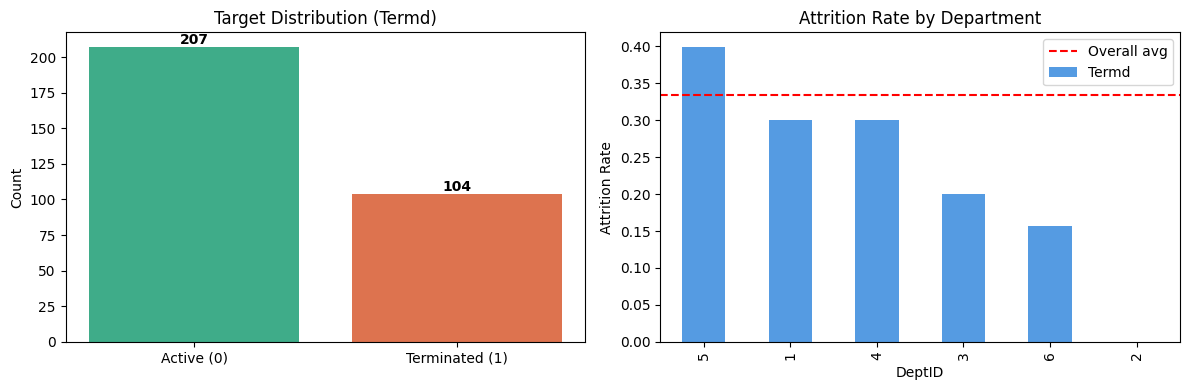

In [9]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_anon['Termd'].value_counts()
axes[0].bar(['Active (0)', 'Terminated (1)'], counts.values,
            color=['#1D9E75', '#D85A30'], alpha=0.85)
axes[0].set_title('Target Distribution (Termd)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Attrition by department (if available)
if 'DeptID' in df_anon.columns:
    dept_attr = df_anon.groupby('DeptID')['Termd'].mean().sort_values(ascending=False)
    dept_attr.plot(kind='bar', ax=axes[1], color='#378ADD', alpha=0.85)
    axes[1].set_title('Attrition Rate by Department')
    axes[1].set_ylabel('Attrition Rate')
    axes[1].set_xlabel('DeptID')
    axes[1].axhline(df_anon['Termd'].mean(), color='red', linestyle='--', label='Overall avg')
    axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/attrition_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

### Correlation heatmap: top features correlated with 'Termd', employment terminated.

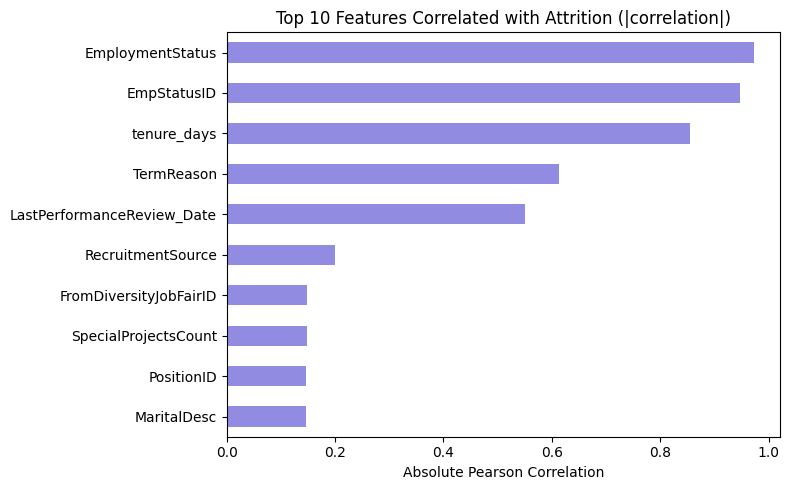

Top correlated features:
EmploymentStatus              0.972487
EmpStatusID                   0.948058
tenure_days                   0.855727
TermReason                    0.613564
LastPerformanceReview_Date    0.550231
RecruitmentSource             0.200198
FromDiversityJobFairID        0.147717
SpecialProjectsCount          0.147429
PositionID                    0.147042
MaritalDesc                   0.146238
Name: Termd, dtype: float64


In [12]:
# Correlation heatmap
corr = df_anon.corr(numeric_only=True)['Termd'].drop('Termd').abs().sort_values(ascending=False)
top_features = corr.head(10)

plt.figure(figsize=(8, 5))
top_features.plot(kind='barh', color='#7F77DD', alpha=0.85)
plt.title('Top 10 Features Correlated with Attrition (|correlation|)')
plt.xlabel('Absolute Pearson Correlation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../docs/feature_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top correlated features:')
print(top_features)

### Pay rate vs. Attrition

In [11]:
# PayRate vs Attrition
if 'PayRate' in df_anon.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    df_anon.boxplot(column='PayRate', by='Termd', ax=axes[0])
    axes[0].set_title('Pay Rate by Attrition Status')
    axes[0].set_xlabel('Termd (0=Active, 1=Left)')

    if 'PerfScoreID' in df_anon.columns:
        perf_attr = df_anon.groupby('PerfScoreID')['Termd'].mean()
        perf_attr.plot(kind='bar', ax=axes[1], color='#EF9F27', alpha=0.85)
        axes[1].set_title('Attrition Rate by Performance Score')
        axes[1].set_xlabel('Performance Score (1=PIP, 4=Exceeds)')
        axes[1].set_ylabel('Attrition Rate')

    plt.tight_layout()
    plt.show()

## 5. Save data after preprocessing

In [15]:
os.makedirs('../data/processed', exist_ok=True)

# Main modeling dataset (anonymized, no sensitive attrs)
df_anon.to_csv('../data/processed/hr_anonymized.csv', index=False)
print(f'Saved hr_anonymized.csv — shape: {df_anon.shape}')

# Sensitive attrs for bias audit only
df_sensitive.to_csv('../data/processed/hr_sensitive_audit.csv', index=False)
print(f'Saved hr_sensitive_audit.csv — shape: {df_sensitive.shape}')

print('\nEDA complete. Ready for 02_model.ipynb')

Saved hr_anonymized.csv — shape: (311, 26)
Saved hr_sensitive_audit.csv — shape: (311, 4)

EDA complete. Ready for 02_model.ipynb
